# Testing AirGravQC oddeven() - Example Data

Mark Dransfield

In [1]:
import datetime
start = datetime.datetime.now()
print(start)

2025-01-01 16:10:45.324246


In [2]:
%matplotlib widget
from pathlib import Path

import AirGravQC as qc

import warnings
warnings.simplefilter('ignore')

## code

### xarray to grid

In [24]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Interpolate point-located data from a 1-D to a 2-D xArray DataArray.
"""
import numpy as np
import xarray as xr
import verde as vd
from scipy.interpolate import griddata

import AirGravQC.utility.utility as util
import AirGravQC.gridFiles.read_ers as ers
import AirGravQC.whizzFiles.retrieveData as rd
import AirGravQC.gridFiles.gridutility as gut
import AirGravQC.config as config

groupName = config.groupName
projectName = config.projectName


def xarray_to_grid(my_data, grid_space, region=[], method='neighbours', mask_polygon=[], mask_pixels=2, numneighbours=5):
    """
    Interpolates `my_data` onto a regular grid.

    Parameters
    ----------
    my_data : xArray Dataset
        Contains x, y, and z data dimensioned by fiducial.
    grid_space : Float
        The distance between grid cell centres in grid distance units.
    region : Array of float, optional
        Coordinates of the corners of the bounding rectangle [West, East, South, North].
        Default uses the minimum and maximum coordinates.
    method : string, optional
        The gridding algorithm to use in interpolating the data. Available are the Verde methods:
        "neighbours" (nearest neighbour); ; and the SciPy GridData "linear" method. "neighbours" is
        much faster if `pykdtree` is installed. Default `neighbours` method.
    mask_polygon : numpy 2D array, optional
        If the size of mask_polygon > 0, then data_array will be masked to the area
        within the polygon defined by it.
    mask_pixels : Integer, optional
        If mask_pixels > 0, then all pixels further than `mask_pixels * grid_space` from a data
        location will be masked out. Default 1.
    numneighbours : Integer, optional
        If method='neighbours', then this is the number of neighbours to average. Default 5.

    Returns
    -------
    grid : xArray DataArray
        Contains the gridded data.
    region : tuple
        Four floating point values for xmin, xmax, ymin, ymax.

    """

    # grid_space = 500.0

    x_chan = my_data.attrs['x_channel']
    y_chan = my_data.attrs['y_channel']
    z_chan = my_data.attrs['z_channel']
    if 'units' in my_data[z_chan].attrs:
        myunits = my_data[z_chan].attrs['units']
    else:
        myunits = "no units"
    print(f'Processing (x, y, z) = ({x_chan}, {y_chan}, {z_chan}). {z_chan} in {myunits}.')

    if method == 'scipy':

        if region == []:
            region = [
                        min(my_data[x_chan].data), 
                        max(my_data[x_chan].data),
                        min(my_data[y_chan].data),
                        max(my_data[y_chan].data)
                    ]
        X = np.arange(region[0], region[1], grid_space)
        Y = np.arange(region[2], region[3], grid_space)

        tmpgrid = xr.DataArray(np.zeros((len(X), len(Y))), coords=[X, Y], dims=['x', 'y'])
        grid = tmpgrid.transpose()

        east, north = np.meshgrid(X, Y)  # 2D grid for interpolation

        grid.values = griddata(list(zip(my_data[x_chan].data, my_data[y_chan].data)), my_data[z_chan].data, (east, north), method='linear')

    # method is one of the Verde methods
    else:
        # 1. Decimate the data along line
        spacing = grid_space / 2.0
        reducer = vd.BlockReduce(reduction=np.median, spacing=spacing)
        coordinates, z_data = reducer.filter(
            (my_data[x_chan].data, my_data[y_chan].data), my_data[z_chan].data
        )
        # 2. Define the grid region and coordinates
        if region == []:
            region = vd.get_region([my_data[x_chan], my_data[y_chan]])
            myreg = float(region[0].values), float(region[1].values), float(region[2].values), float(region[3].values)
        else:
            myreg = float(region[0]), float(region[1]), float(region[2]), float(region[3])

        east, north = vd.grid_coordinates(region=myreg, spacing=grid_space)
        
        # 3. Grid by the chosen method
        if method == 'neighbours':
            grd = vd.KNeighbors(k=numneighbours)
            grd.fit((my_data[x_chan], my_data[y_chan]), my_data[z_chan])
        elif method == 'bicubic':
            grd = vd.Cubic().fit((my_data[x_chan], my_data[y_chan]), my_data[z_chan])
        elif method == 'biharmonic':
            grd = vd.Spline(damping=1e-10)
            grd.fit(coordinates, z_data)
        else:
            print('Error - method must be "scipy", "neighbours", "bicubic", "biharmonic".')
            return
        
        # 4. Tidy up ...
        my_grid_ds = grd.grid(coordinates=(east, north) )
        my_grid = my_grid_ds.to_array()
        my_grid = my_grid.squeeze('variable')
        grid = my_grid.rename({'easting': 'x','northing': 'y'})

    if np.array(mask_polygon).size > 0:
        grid = gut.maskGridByPolygon(grid, mask_polygon, x_chan='x', y_chan='y')

    if mask_pixels > 0:
        mymask = vd.distance_mask(
            (my_data[x_chan], my_data[y_chan]),
            maxdist = grid_space * mask_pixels,
            coordinates = (east, north),
        )
        grid = grid.where(mymask)


    grid.attrs['units'] = myunits
    grid.attrs['long_name'] = z_chan
    grid.attrs['title'] = my_data.attrs['title']
    grid['x'].attrs['orig_name'] = x_chan
    grid['y'].attrs['orig_name'] = y_chan

    return grid, region

### xdimage

In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Display the gridded (raster) data in an xArray DataArray
"""
import numpy as np

import AirGravQC.utility.utility as util
import AirGravQC.gridFiles.read_ers as ers
import AirGravQC.whizzFiles.retrieveData as rd
import AirGravQC.config as config
import AirGravQC.gridFiles.gridutility as gut

from AirGravQC.gridFiles.graphicsShaded import graphicsShaded

groupName = config.groupName
projectName = config.projectName


def xdImage(data_array, mytitle, colormap=config.qc_colormap, cmap_norm='nonorm', 
        minClip=np.nan, maxClip=np.nan, gridlines=True, cb_ticks='stats', nSigma=2,
        hs=True, azdeg=45, ax=None, clipTo3Std=False, mask_polygon=[],
                   whizzfile=None, e_chan='', n_chan=''):
    """
    Uses `graphicsShaded()` to display the gridded data in data_array. All
    parameters after the name of the whizzFile are just passed through
    to `graphicsShaded()`.

    Parameters
    ----------
    data_array : 2D xarray
        The data to be imaged.
    mytitle : String
        The figure title.
    colormap : Colormap, optional
        A colour map, eg cc.m_CET_L9. The default is config.qc_colormap.
    cmap_norm : String, optional
        Must be one of 'nonorm' (no normalisation, ie linear stretch); 'equalize'
        (equalization stretch); 'auto'. The default is 'nonorm'.
    minClip : Float, optional
        z -> z < minClip : minClip: z. The default is np.nan - no clipping.
    maxClip : Float, optional
        z -> z > maxClip : maxClip: z. The default is np.nan - no clipping.
    gridlines : Bool, optional
        If True (the default), then grid lines are drawn on the image, else not.
    cb_ticks : TYPE, optional
        DESCRIPTION. The default is 'stats'.
    nSigma : TYPE, optional
        Not currently used. The default is 2.
    hs : Bool, optional
        hill-shading. The default is True.
    azdeg: Float, optional
        The shading azimuth in degrees from north, defaults to 45 deg.
    ax : Axis, optional
        The Matplotlib figure axis to be plotted to. Default None, in which case a new
        figure is made.
    clipTo3Std : Boolean, optional
        If True (the default), the data are clipped to +/- 3 standard deviations from
        the mean before imaging. This over-rides minClip and maxClip.
    mask_polygon : numpy 2D array, optional
        If the size of mask_polygon > 0, then data_array will be masked to the area
        within the polygon defined by it.

    Returns
    -------
    None.

    """

    if np.array(mask_polygon).size > 0:
        data_array = gut.maskGridByPolygon(data_array, mask_polygon, x_chan='x', y_chan='y')
    vmin = np.nan
    vmax = np.nan

    if 'units' in data_array.attrs:
        cb_title = data_array.attrs['units']
    else:
        cb_title = ''
    
    fd_mean = data_array.mean()
    fd_std = data_array.std()
    if clipTo3Std:
        a = fd_mean - 3.0 * fd_std
        vmin = a.data * 1
        a = fd_mean + 3.0 * fd_std
        vmax = 1 * a.data
    elif ~np.isnan(minClip + maxClip):
        vmin = minClip
        vmax = maxClip

    if 'E' in list(data_array.coords):
        data_array = data_array.rename({'E': 'x','N': 'y'})
    
    graphicsShaded(data_array.x, data_array.y, data_array, mytitle, colormap, cmap_norm, minClip=vmin, maxClip=vmax, gridlines=gridlines, 
                   cb_ticks=cb_ticks, nSigma=nSigma, hs=hs, azdeg=azdeg, ax=ax, origin='lower', cb_title=cb_title,
                   whizzfile=whizzfile, e_chan=e_chan, n_chan=n_chan)


def xdsImage(data_set, mytitle, colormap=config.qc_colormap, cmap_norm='nonorm', 
        minClip=np.nan, maxClip=np.nan, gridlines=True, cb_ticks='stats', nSigma=2,
        hs=True, azdeg=45, ax=None, clipTo3Std = True, mask_polygon=[]):
    """
    Uses `graphicsShaded()` to display the gridded data in data_array. All
    parameters after the name of the whizzFile are just passed through
    to `graphicsShaded()`.

    Assumes only one DataArray in the xarray dataset

    Parameters
    ----------
    data_set : 2D xarray dataset
        The first dataArray in dataSet will be imaged.
    mytitle : String
        The figure title.
    colormap : Colormap, optional
        A colour map, eg cc.m_CET_L9. The default is config.qc_colormap.
    cmap_norm : String, optional
        Must be one of 'nonorm' (no normalisation, ie linear stretch); 'equalize'
        (equlaization stretch); 'auto'. The default is 'nonorm'.
    minClip : Float, optional
        z -> z < minClip : minClip: z. The default is np.nan - no clipping.
    maxClip : Float, optional
        z -> z > maxClip : maxClip: z. The default is np.nan - no clipping.
    cb_ticks : TYPE, optional
        DESCRIPTION. The default is 'stats'.
    nSigma : TYPE, optional
        Not currently used. The default is 2.
    hs : Bool, optional
        hill-shading. The default is True.
    azdeg: Float, optional
        The shading azimuth in degrees from north, defaults to 45 deg.
    ax : Axis, optional
        The Matplotlib figure axis to be plotted to. Default None, in which case a new
        figure is made.
    clipTo3Std : Boolean, optional
        If True (the default), the data are clipped to +/- 3 standard deviations from
        the mean before imaging. This over-rides minClip and maxClip.
    mask_polygon : numpy 2D array, optional
        If the size of mask_polygon > 0, then data_array will be masked to the area
        within the polygon defined by it.

    Returns
    -------
    None.

    """

    first_data = data_set.to_array()
    first_data = first_data.squeeze('variable')
    xdImage(first_data, mytitle, colormap=colormap, cmap_norm=cmap_norm, 
        minClip=minClip, maxClip=maxClip, gridlines=gridlines, cb_ticks=cb_ticks, nSigma=nSigma,
        hs=hs, azdeg=azdeg, ax=ax, clipTo3Std=clipTo3Std, mask_polygon=mask_polygon)

### oddeven

In [14]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Perform odd-even analysis of a channel of data in a `whizz_file`.
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import xarray as xr
import netCDF4 as nc4
import filebrowser as fb
import rioxarray
import h5py
import matplotlib.ticker as tkr
import collections

import AirGravQC.gridFiles.graphics as graphics
import AirGravQC.utility.utility as util
import AirGravQC.gridFiles.read_ers as ers
import AirGravQC.whizzFiles.retrieveData as rd
import AirGravQC.config as config
from AirGravQC.gridFiles.graphicsShaded import graphicsShaded
from AirGravQC.gridFiles.whizz_to_xarray import whizz_to_xarray
# from AirGravQC.gridFiles.xarray_to_grid import xarray_to_grid
# from AirGravQC.gridFiles.xdImage import xdImage
import AirGravQC.gridFiles.gridutility as gut


groupName = config.groupName
projectName = config.projectName


def updateLineTracks(whizzFile, lines=[], x='', y='', trackError=5.0, verbose=False):
    """
    Writes the mean line track direction as an attribute for each flight-line,
    writes it as a line attribute and sets the `LineVariety` attribute to 'Control'
    or 'Traverse'.

    Parameters
    ----------
    whizzFile : Path or String
        The Path to, or String name of, the whizz file in HDF5 format.
    lines : String Array, optional
        List of lines to have their track set. Default all lines.
    x : String, optional
        The name of the x (easting) channel in `whizz_file`. Default is to use
        the `XChannel` attribute.
    y : String, optional
        The name of the y (northing) channel in `whizz_file`. Default is to use
        the `YChannel` attribute.
    trackError : Float, optional IGNORED FOR NOW!
        Any track with +/- trackError degrees of another track is assumed to
        have the same nominal direction. Default is 5.0 degrees.
    verbose : Bool, optional
        The verbosity of output. Default False.

    Returns
    -------
    Nothing.

    """
    filename = str(whizzFile)
    with h5py.File(filename, 'r+') as f:
        g = f[groupName]['Lines']
        if lines == []:
            lines = list(g.keys())
        if x == '':
            x = f[groupName]['CoordinateFrame'].attrs['XChannel']
        if y == '':
            y = f[groupName]['CoordinateFrame'].attrs['YChannel']

        numlines = len(lines)
        tracks = np.zeros((numlines,))

        # assign mean track to line `MeanTrack` attribute
        for idx, line in enumerate(lines):
            mean_track = calcMeanTrack(g[line], x, y)
            g[line].attrs['MeanTrack'] = mean_track
            tracks[idx] = mean_track

        # Traverses are more common than controls
        tracksDict = collections.Counter(np.round(tracks, -1))
        traverseTrack = tracksDict.most_common()[0][0] % 180.0
        print(f'Traverse track = {traverseTrack:.1f} degrees (relative East).')
        controlsTrack = (traverseTrack - 90) % 180.0
        print(f'Controls track = {controlsTrack:.1f} degrees (relative East).')

        # set Control / Traverse attribute
        # WARNING - assigning all non-traverses to 'Control'
        for line in lines:
            gg = g[line]
            if np.round(gg.attrs['MeanTrack'] - traverseTrack, -1) == 0.0: # refine this test using trackError
                gg.attrs['LineVariety'] = 'Traverse'
            elif np.round(gg.attrs['MeanTrack'] - traverseTrack, -1) == 180.0: # refine this test using trackError
                gg.attrs['LineVariety'] = 'Traverse'
            elif np.round(gg.attrs['MeanTrack'] - controlsTrack, -1) == 0.0:
                gg.attrs['LineVariety'] = 'Control'
            elif np.round(gg.attrs['MeanTrack'] - controlsTrack, -1) == 180.0:
                gg.attrs['LineVariety'] = 'Control'
            else:
                gg.attrs['LineVariety'] = 'Unknown'
                mean_track = gg.attrs['MeanTrack']
                print(f'Line {line} has unknown line purpose (track = {mean_track:.1f}).')
            if verbose:
                line_purpose = gg.attrs['LineVariety']
                print(f'Line {line} is {line_purpose} on track {gg.attrs["MeanTrack"]:.1f}')


def calcMeanTrack(lineGroup, easting, northing):
    """
    Return the aircraft track for the flight-line. The track is the angle
    (in degrees) from North in a clockwise direction.

    Parameters
    ----------
    linegroup : HDF5 group
        A whizzFile line group.
    easting : String
        The name of the x (easting) channel in `linegroup`.
    northing : String
        The name of the y (northing) channel in `linegroup`.

    Returns
    -------
    track : float
        The mean aircraft track angle east of north in [0, 180] degrees.

    """
    # calculate the by-sample track direction
    dx = np.mean(np.diff(rd.getLineData(lineGroup, easting)))
    dy = np.mean(np.diff(rd.getLineData(lineGroup, northing)))
    # arctan returns angle north from east and [-pi, pi] range
    theta = np.arctan2(dy, dx) * 180.0 / np.pi
    # use east from north and [0, 180] range.
    track = (90.0 - theta) % 180.0
    return track


def oddevenlines(whizz_file, channel, grid_space, oddlines=[], evenlines=[], method='neighbours', mask_polygon=[], mask_pixels=1, numneighbours=1, hs=True):
    """
    Performs odd-even analysis of the `channel` data in `whizz_file`. The data are
    sorted into two sets of odd and even lines. Each set is gridded and the difference
    of the grids is imaged, and its RMS value reported as an estimate of the error in
    the data.

    Parameters
    ----------
    whizz_file : String or pathlib Path
        Name of a HDF5 Whizz file, including path and extension.
    channel : String
        The channel or field name to analyse. Must exist in `whizz_file`.
    grid_space : Float
        The width of the grid cell to be used in gridding. Recommend: 1/5 - 1/4 line spacing.
    oddlines : Array of String, optional
        An array of line numbers that will constitute the odd lines. The default is NOT WORKING! ...to take the first,
        and then every second traverse thereafter.
    evenlines : Array of String, optional
        An array of line numbers that will constitute the even lines. The default is NOT WORKING! ...to take every
        second traverse (alternates to the oddlines).
    mask_polygon : numpy 2D array, optional
        If the size of mask_polygon > 0, then data_array will be masked to the area
        within the polygon defined by it.
    mask_pixels : Integer, optional
        If mask_pixels > 0, then all pixels further than `mask_pixels * grid_space` from a data
        location will be masked out. Default 1.
    numneighbours : Integer, optional
        If method='neighbours', then this is the number of neighbours to average. Default 5.

    Returns
    -------
    None.

    """

    if np.array(oddlines).size == 0 or np.array(evenlines).size == 0:
        oddlines, evenlines = _getOddEvenLines(str(whizz_file))

    # Read data to xarrays.
    even_data = whizz_to_xarray(whizz_file, channel, n_chan='', e_chan='', lines=evenlines, remove_mean=False, diff_one=False)
    odd_data = whizz_to_xarray(whizz_file, channel, n_chan='', e_chan='', lines=oddlines, remove_mean=False, diff_one=False)

    # Find the coverage for each gridded data set
    e_chan = even_data.attrs['x_channel']
    n_chan = even_data.attrs['y_channel']
    even_region = [
                    np.min(even_data[e_chan].values),
                    np.max(even_data[e_chan].values),
                    np.min(even_data[n_chan].values),
                    np.max(even_data[n_chan].values)
                ]
    odd_region = [
                    np.min(odd_data[e_chan].values),
                    np.max(odd_data[e_chan].values),
                    np.min(odd_data[n_chan].values),
                    np.max(odd_data[n_chan].values)
                ]

    # We are only interested in the statistics over the intersection of the regions.
    intersectregion = [
                        max(even_region[0], odd_region[0]),
                        min(even_region[1], odd_region[1]),
                        max(even_region[2], odd_region[2]),
                        min(even_region[3], odd_region[3]),
                        ]
                        
    # Grid and difference the data sets
    even_grid, even_region = xarray_to_grid(even_data, grid_space, region=intersectregion, method=method, 
        mask_polygon=mask_polygon, mask_pixels=mask_pixels, numneighbours=numneighbours)
    odd_grid, odd_region = xarray_to_grid(odd_data, grid_space, region=intersectregion, method=method, 
        mask_polygon=mask_polygon, mask_pixels=mask_pixels, numneighbours=numneighbours)
    d_grid = even_grid - odd_grid

    # Subtraction does not preserve attributes
    d_grid.attrs['units'] = even_grid.attrs['units']
    d_grid.attrs['long_name'] = even_grid.attrs['long_name']
    d_grid.attrs['title'] = f"even minus odd : {even_grid.attrs['title']}"
    d_grid['x'].attrs['orig_name'] = even_grid['x'].attrs['orig_name']
    d_grid['y'].attrs['orig_name'] = even_grid['y'].attrs['orig_name']

    # Image and report statistics

    # xdImage(d_grid, d_grid.attrs['title'], cmap_norm='nonorm', 
    #     nSigma=2, clipTo3Std = True)
    xdImage(d_grid, d_grid.attrs['title'], colormap=config.qc_colormap, cmap_norm='nonorm', 
        minClip=np.nan, maxClip=np.nan, gridlines=True, cb_ticks='stats', nSigma=2,
        hs=hs, azdeg=45, ax=None, clipTo3Std = True)

    gut.report_gridStats(d_grid, mask_polygon=mask_polygon)


def _getOddEvenLines(whizz_file):
    """
    Returns the flight-lines in `whizz_file` sorted into odd lines and even lines,
    according to the line attribute `Parity`.

    Parameters
    ----------
    whizz_file : String or pathlib Path
        Name of a HDF5 Whizz file, including path and extension.

    Returns
    -------
    oddlines : list of string
        The Odd survey lines.
    evenlines : list of string
        The Even survey lines.

    """

    filename = str(whizz_file)
    numevens = 0
    evenlines = []
    numodds = 0
    oddlines = []
    
    with h5py.File(filename, 'r') as f:
        lines_group = f[groupName]['Lines']
        lines = lines_group.keys()
        
        for line in lines:
            # Only want Traverse lines
            lineIsTraverse = False
            try:
                if lines_group[line].attrs['LineVariety'] == 'Traverse':
                    lineIsTraverse = True
                else:
                    continue
            except:
                continue

            # 
            if "Parity" in lines_group[line].attrs.keys():
                if lines_group[line].attrs["Parity"]:
                    oddlines.append(line)
                    numodds += 1
                else:
                    evenlines.append(line)
                    numevens += 1

    print(f'{numevens} even lines, {numodds} odd lines.')
    return oddlines, evenlines


def _getTravCtrlLines(whizz_file):
    """
    Returns the flight-lines in `whizz_file` sorted into traverse lines and control lines,
    according to the line attribute `LineVariety`.

    Parameters
    ----------
    whizz_file : String or pathlib Path
        Name of a HDF5 Whizz file, including path and extension.

    Returns
    -------
    travlines : list of string
        The Traverse survey lines.
    ctrllines : list of string
        The Control survey lines.

    """

    filename = str(whizz_file)
    numtravs = 0
    travlines = []
    numctrls = 0
    ctrllines = []
    
    with h5py.File(filename, 'r') as f:
        lines_group = f[groupName]['Lines']
        lines = lines_group.keys()
        numlines = len(lines)
        
        for line in lines:
            if "LineVariety" in lines_group[line].attrs.keys():
                if lines_group[line].attrs["LineVariety"] == "Traverse":
                    travlines.append(line)
                    numtravs += 1
                elif lines_group[line].attrs["LineVariety"] == "Control":
                    ctrllines.append(line)
                    numctrls += 1

    print(f'{numtravs} traverse lines, {numctrls} control lines, {numlines - numctrls - numtravs} not classified.')
    return travlines, ctrllines

## test Canobie

In [3]:
local_docs = "/Users/markdransfield/"
# local_docs = "/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/"

data_root = local_docs + "Documents/GitHub/AirGravQC/examples/SourceData/"
canobieXYZ_file = Path(data_root + r'Canobie_BG.xyz')
canobieHDF_file = canobieXYZ_file.with_suffix('.hdf5')


In [4]:
plan_root = data_root
canobieXYZ_plan = Path(plan_root + r'CanobiePlan.xyz')
canobieHDF_plan = canobieXYZ_plan.with_suffix('.hdf5')

38 even lines, 39 odd lines.
38 lines; total number of fids in whizz file = 310150.
    FSF_gD_2p67: min = -215.5, max = 472.4.
39 lines; total number of fids in whizz file = 321959.
    FSF_gD_2p67: min = -215.9, max = 473.1.
Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.


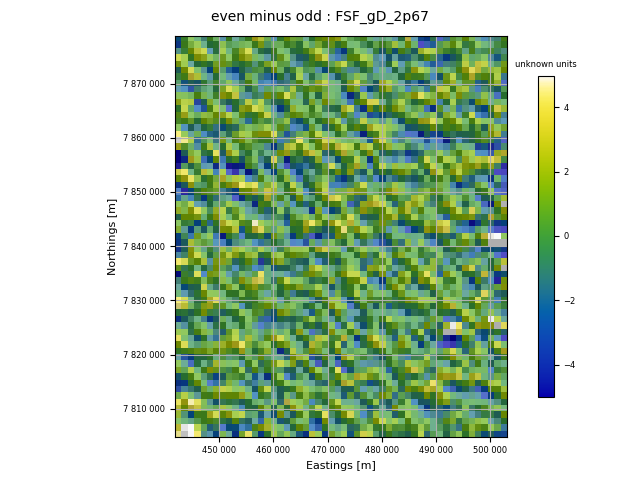

RMS of result = 1.66 unknown units


In [5]:
qc.oddevenlines(canobieHDF_file, 'FSF_gD_2p67', 1200.0, method='biharmonic')

38 even lines, 39 odd lines.
38 lines; total number of fids in whizz file = 310150.
    FSF_gD_2p67: min = -215.5, max = 472.4.
39 lines; total number of fids in whizz file = 321959.
    FSF_gD_2p67: min = -215.9, max = 473.1.
Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.
Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.


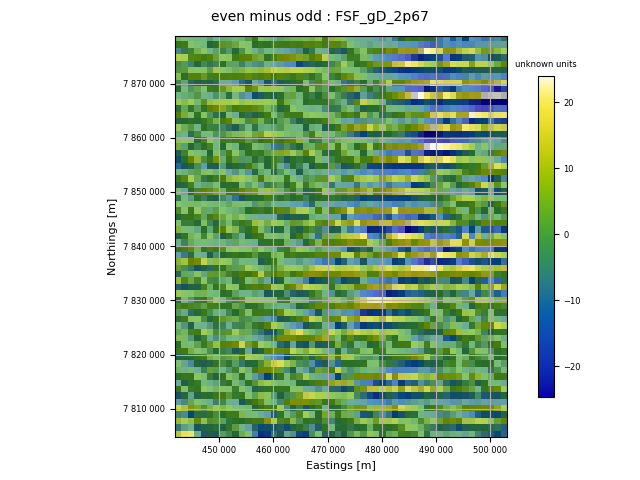

RMS of result = 8.11 unknown units


In [6]:
qc.oddevenlines(canobieHDF_file, 'FSF_gD_2p67', 1200.0, method='neighbours')

38 even lines, 39 odd lines.
38 lines; total number of fids in whizz file = 310150.
    FSF_gD_2p67: min = -215.5, max = 472.4.
39 lines; total number of fids in whizz file = 321959.
    FSF_gD_2p67: min = -215.9, max = 473.1.
Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.
Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.


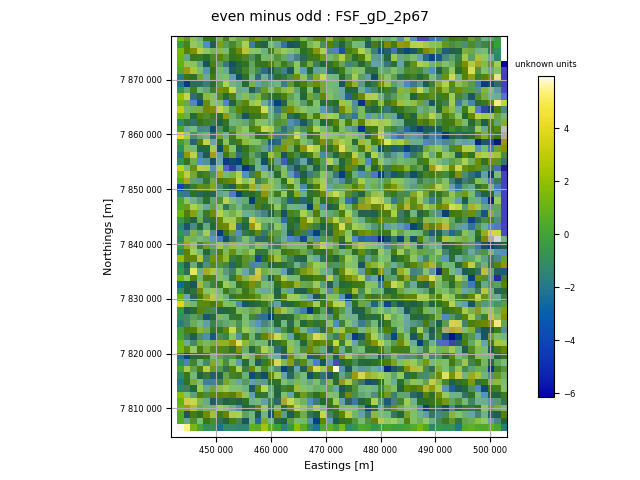

RMS of result = 2.02 unknown units


In [7]:
qc.oddevenlines(canobieHDF_file, 'FSF_gD_2p67', 1200.0, method='scipy')

38 even lines, 39 odd lines.
38 lines; total number of fids in whizz file = 310150.
    FSF_gD_2p67: min = -215.5, max = 472.4.
39 lines; total number of fids in whizz file = 321959.
    FSF_gD_2p67: min = -215.9, max = 473.1.
Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.
Processing (x, y, z) = (X_GDA2020, Y_GDA2020, FSF_gD_2p67). FSF_gD_2p67 in unknown units.


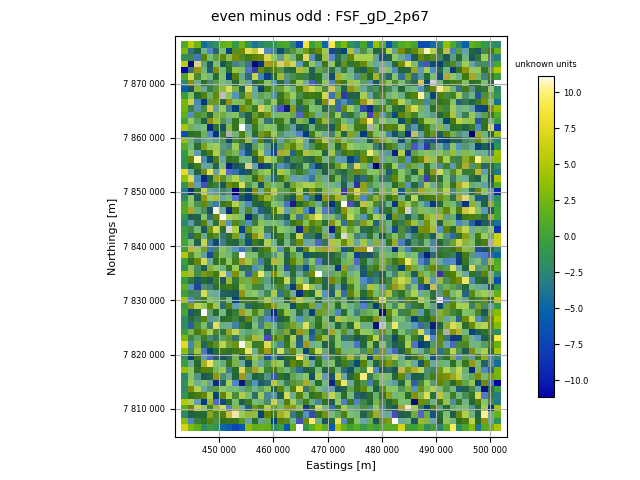

RMS of result = 3.72 unknown units


In [8]:
qc.oddevenlines(canobieHDF_file, 'FSF_gD_2p67', 1200.0, method='bicubic')

## Georgetown AEM gravity odd-even test

In [9]:
root = r'/Volumes/MHD Data2024/ActiveSurveys/202406_GA8097_GeorgetownAEM/'

plan_root = root + r'plan/'
px = Path(plan_root + 'GeorgetownAEM_GravityLines.xyz')
ph = px.with_suffix('.hdf5')

located_root = root + r'data/20241217_Gravity/'
dx = Path(located_root + r'NRGA2347_Master_ums_field_final.xyz')
dh = dx.with_suffix('.hdf5')

58 even lines, 57 odd lines.
58 lines; total number of fids in whizz file = 2141038.
    FA_8_L_5000: min = -393.2741, max = 141.4702.
57 lines; total number of fids in whizz file = 2210451.
    FA_8_L_5000: min = -398.803, max = 142.1226.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.


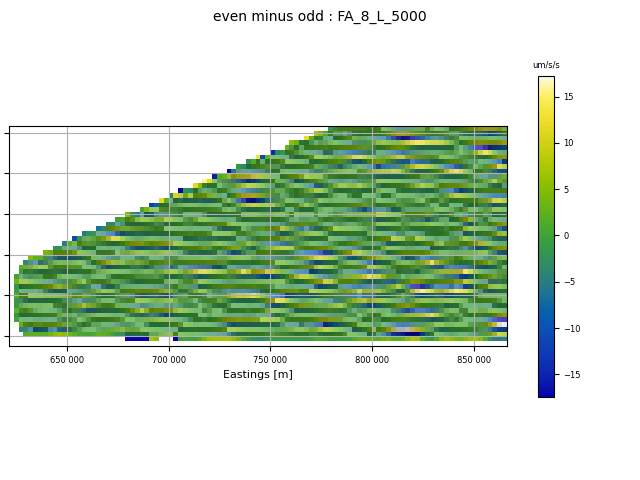

RMS of result = 5.77 um/s/s


In [12]:
qc.oddevenlines(dh, 'FA_8_L_5000', 2400.0, method='scipy', mask_pixels=1)

58 even lines, 57 odd lines.
58 lines; total number of fids in whizz file = 2141038.
    FA_8_L_5000: min = -393.2741, max = 141.4702.
57 lines; total number of fids in whizz file = 2210451.
    FA_8_L_5000: min = -398.803, max = 142.1226.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.


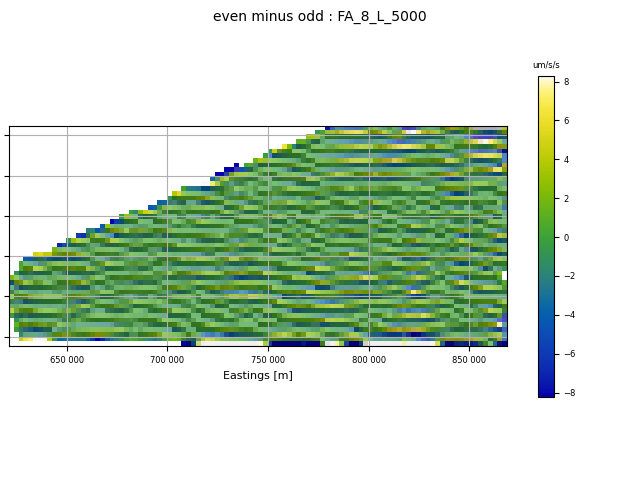

RMS of result = 2.75 um/s/s


In [13]:
qc.oddevenlines(dh, 'FA_8_L_5000', 2400.0, method='biharmonic', mask_pixels=1)

58 even lines, 57 odd lines.
58 lines; total number of fids in whizz file = 2141038.
    FA_8_L_5000: min = -393.2741, max = 141.4702.
57 lines; total number of fids in whizz file = 2210451.
    FA_8_L_5000: min = -398.803, max = 142.1226.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.


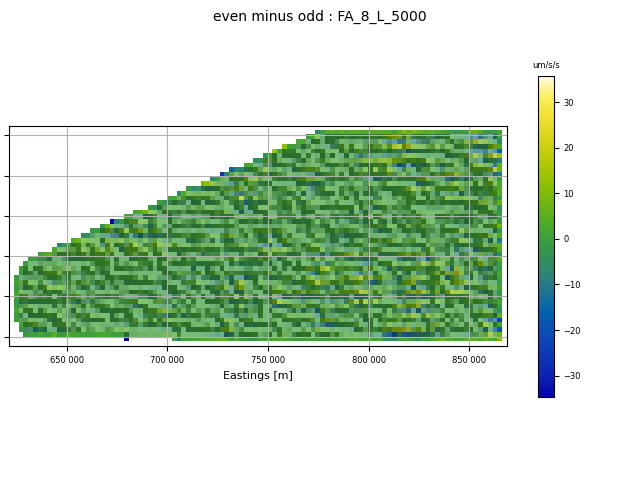

RMS of result = 11.73 um/s/s


In [14]:
qc.oddevenlines(dh, 'FA_8_L_5000', 2400.0, method='bicubic', mask_pixels=1)

58 even lines, 57 odd lines.
58 lines; total number of fids in whizz file = 2141038.
    FA_8_L_5000: min = -393.2741, max = 141.4702.
57 lines; total number of fids in whizz file = 2210451.
    FA_8_L_5000: min = -398.803, max = 142.1226.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.
Processing (x, y, z) = (X_GRV, Y_GRV, FA_8_L_5000). FA_8_L_5000 in um/s/s.


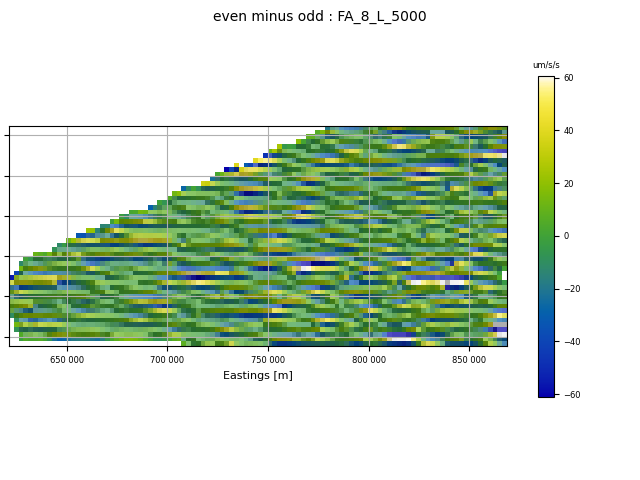

RMS of result = 20.28 um/s/s


In [15]:
qc.oddevenlines(dh, 'FA_8_L_5000', 2400.0, method='neighbours', numneighbours=3, mask_pixels=1)

## Clean up

In [16]:
warnings.resetwarnings()